In [239]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/.local/lib/python3.10/site-packages/numpy/__init__.py
/home/govind/.local/lib/python3.10/site-packages/matplotlib/pyplot.py


In [240]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import stellate
import importlib
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)



0.0

In [241]:
stellate_0 = stellate.Stellate(0)

stell_comb_ic = h.IClamp(stellate_0.soma(0.5))
stell_comb_ic.dur = 1e9

time_dur = 12000

time_steps = int(time_dur / h.dt)
time_arr = np.arange(0,time_dur,h.dt)

input_amp = -3.1e-3
theta_amp = 1e-4
theta_freq = 10.0

initial_phase = 0.0
mean,std=0,1e-5

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
input_rec = h.Vector().record(stell_comb_ic._ref_amp)

nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



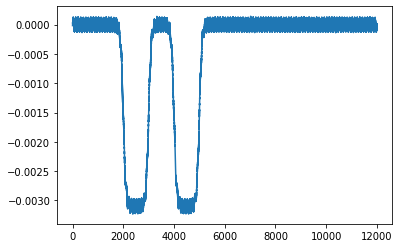

In [242]:
def input_func(t_ms):
    first_term = 0.5 * (np.tanh((t_ms - 2000)/100) - np.tanh((t_ms - 3000)/100))
    second_term = 0.5 * (np.tanh((t_ms - 4000)/100) - np.tanh((t_ms - 5000)/100))
    theta_term = theta_amp * np.sin(2 * np.pi * theta_freq * t_ms / 1000 + initial_phase)
    return (input_amp*(first_term + second_term)) + theta_term

noise_input = np.random.normal(0,std,time_steps)
stell_input = input_func(time_arr) + noise_input
plt.plot(time_arr,stell_input)
plt.show()

In [314]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 0.01 
g_max = 0.005
g_theta_amp = 0.1
g_base = 0
theta_freq = 10.0    

def conductance_func(t_ms):

    mask = ((t_ms>=1900)&(t_ms<=3600)) | ((t_ms>=7900)&(t_ms<=9600))
    
    pulse_1 = 0.5 * (np.tanh((t_ms - 2000)/200) - np.tanh((t_ms - 3500)/200)) + 0.0008
    pulse_2 = 0.5 * (np.tanh((t_ms - 7500)/500) - np.tanh((t_ms - 9000)/500)) + 0.0008
    envelope = pulse_1 + pulse_2
    
    oscillations = g_theta_amp*(np.sin(np.pi * theta_freq * t_ms / 1000 + initial_phase))**2
    
    return 10*(g_max * envelope * (0.7 + 0.3 * oscillations)) 


stell_g_input = conductance_func(time_arr)
stell_g_input += np.random.normal(0, 1e-5, len(time_arr))
stell_g_input = np.clip(stell_g_input, 0, None)

g_vec = h.Vector(stell_g_input)
g_vec.play(syn_inh._ref_g, h.dt)


g_rec = h.Vector().record(syn_inh._ref_g)

h.finitialize(-65)
h.frecord_init()
h.continuerun(time_dur)



0.0

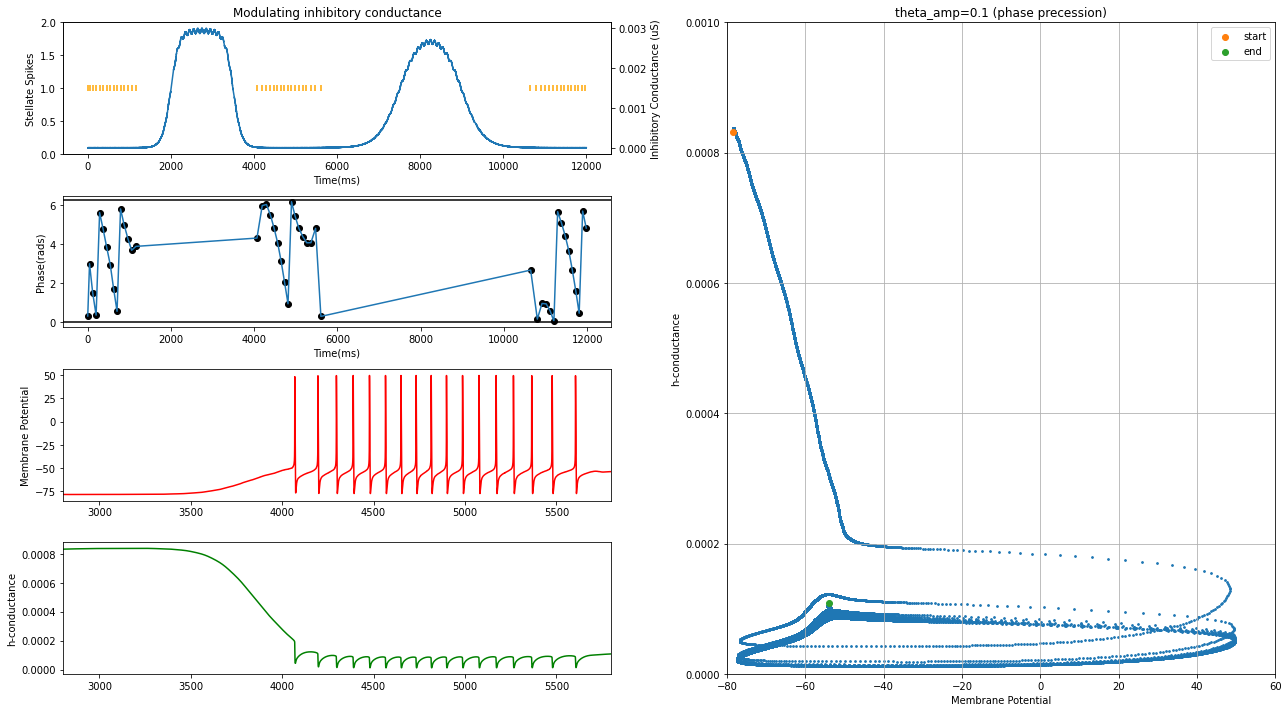

In [315]:

from matplotlib.gridspec import GridSpec

spike_times_array = np.array(spike_times_stell.to_python())
phases = (((spike_times_array) * theta_freq * 2 * np.pi / 1000) + initial_phase) % (2 * np.pi)
g_rec_array = np.array(g_rec.to_python())

volt_dyn = np.array(stell_v.to_python())
hcond_dyn = np.array(stellate_gh_vec.to_python())

start = 2800
end = 5800

fig = plt.figure(figsize=(18,10))
gs = GridSpec(4,2, width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])

ax0_twin = ax0.twinx()
ax0.eventplot(spike_times_array, label="Stellate Spikes", color='orange', linelengths=0.1)
ax0.set_ylim(0,2)
#ax0.set_xlim(start,end)
ax0.set_ylabel('Stellate Spikes')
ax0.set_xlabel('Time(ms)')
ax0.set_title("Modulating inhibitory conductance")

ax0_twin.plot(time, g_rec_array, label="Input")
ax0_twin.set_ylabel('Inhibitory Conductance (uS)')

ax1.plot(spike_times_array, phases)
ax1.scatter(spike_times_array, phases, color='black')
ax1.set_xlabel("Time(ms)")
#ax1.set_xlim(start,end)
ax1.set_ylabel("Phase(rads)")
ax1.axhline(y=2*np.pi, color='black')
ax1.axhline(y=0, color='black')

ax2.plot(time, stell_v, color='red')
ax2.set_ylabel("Membrane Potential")
ax2.set_xlim(start,end)
ax3.plot(time, stellate_gh_vec, color='green')
ax3.set_ylabel("h-conductance")
ax3.set_xlim(start,end)

ax_phase.scatter(volt_dyn[start*40:end*40], hcond_dyn[start*40:end*40], s=3)
ax_phase.scatter(volt_dyn[start*40], hcond_dyn[start*40], label='start')
ax_phase.scatter(volt_dyn[end*40], hcond_dyn[end*40], label='end')

ax_phase.set_xlabel("Membrane Potential")
ax_phase.set_ylabel("h-conductance")
ax_phase.set_title("theta_amp=0.1 (phase precession)")
ax_phase.set_ylim(0,0.001)
ax_phase.set_xlim(-80,60)
ax_phase.grid(True)
ax_phase.legend()

plt.tight_layout()
plt.show()

480001


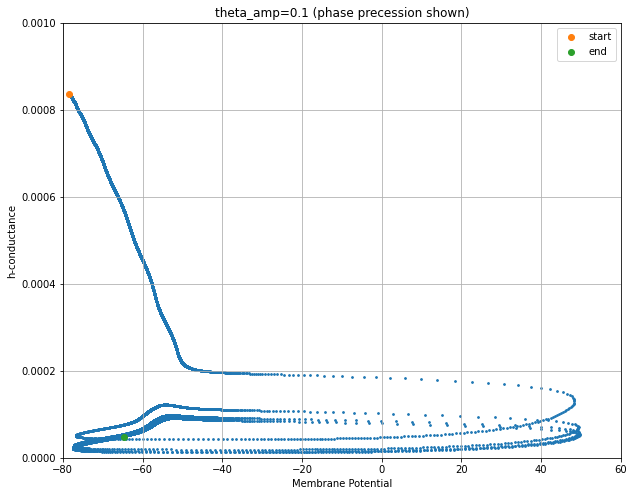

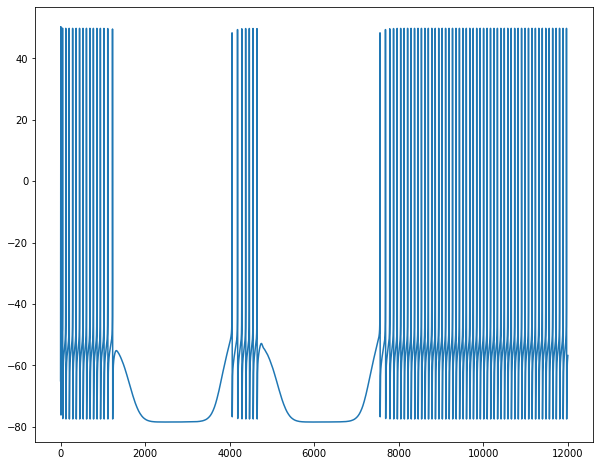

In [163]:
def phase_prec_rate(spike_times,spike_phases):
    times = np.array(spike_times)
    phi_unwrap = np.unwrap(spike_phases)
    beta, alpha = np.polyfit(times, phi_unwrap, 1)

    return beta
print(np.unwrap(phases))


[ 0.30630528 -1.38230077 -0.6832964  -0.51993358 -0.47438049 -0.46024332
 -0.45710173 -0.45396014 -0.44610616 -0.4288274  -0.38013271 -0.24504423
  0.16179202 -0.82780967 -0.00942478 -0.01099558 -0.17435839 -0.26075219
 -0.19477875  0.18378317 -0.82780967 -0.01256638 -0.02042036 -0.20263273
 -0.33772122 -0.40683625 -0.43668138 -0.44924775 -0.45396014 -0.45553094
 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173
 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173
 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173
 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710173
 -0.45710173 -0.45710173 -0.45710173 -0.45710173 -0.45710172 -0.45710172
 -0.45710172 -0.45710172 -0.45710172 -0.45710172 -0.45710172]
